=================================================================
⚡ ÜRETİM ENERJİ VERİMLİLİĞİ ANALİZİ
=================================================================

İŞ PROBLEMİ:
Bir üretim tesisinde 300 makine 7/24 çalışmakta ve aylık elektrik
maliyeti $50,000'ı aşmaktadır. Bu proje, makine sensör verilerini
kullanarak:

1. Enerji tüketimi driver'larını belirlemeyi
2. %10-15 tasarruf potansiyeli olan alanları tespit etmeyi
3. Veri odaklı optimizasyon önerileri sunmayı hedeflemektedir.

POTANSIYYEL DEĞER: $60,000 - $90,000/yıl tasarruf

VERİ KAYNAĞI: Kaggle - Machine Predictive Maintenance Classification
(Yeniden çerçevelerek enerji analizi için kullanıldı)


GEREKLİ KÜTÜPHANELER YÜKLENDİ.

In [1]:
# Veri manipülasyonu
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# İstatistiksel analiz
from scipy import stats
from scipy.stats import pearsonr

# Uyarıları kapat
import warnings
warnings.filterwarnings('ignore')

# Görsel ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Kütüphaneler yüklendi")

✅ Kütüphaneler yüklendi


VERİLER YÜKLENDİ.

In [2]:
# Google Drive'ı bağla (Colab için)
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Veriyi yükle (senin dosya yolunu güncelle)
file_path = '/content/drive/MyDrive/Data-Analyst-Portfolio/Project-2-energy-efficiency-analysis/data/raw/predictive_maintenance.csv'
df = pd.read_csv(file_path)

print(f"✅ Veri yüklendi: {df.shape[0]} satır, {df.shape[1]} kolon")
df.head()

Mounted at /content/drive
✅ Veri yüklendi: 10000 satır, 10 kolon


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


Veri inceleme

In [3]:
# Genel bilgi
print("=" * 70)
print("VERİ SETİ GENEL BİLGİLER")
print("=" * 70)
print(f"📊 Toplam kayıt sayısı: {df.shape[0]:,}")
print(f"📋 Kolon sayısı: {df.shape[1]}")
print(f"💾 Bellek kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n")

# Veri tipleri
print("VERI TIPLERİ:")
print(df.dtypes)
print("\n")

# Eksik veri kontrolü
print("EKSİK VERİ ANALİZİ:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ Eksik veri yok - veri kalitesi yüksek!")
else:
    print(missing[missing > 0])
print("\n")

# İstatistiksel özet
print("İSTATİSTİKSEL ÖZET:")
df.describe().round(2)

VERİ SETİ GENEL BİLGİLER
📊 Toplam kayıt sayısı: 10,000
📋 Kolon sayısı: 10
💾 Bellek kullanımı: 2.10 MB


VERI TIPLERİ:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object


EKSİK VERİ ANALİZİ:
✅ Eksik veri yok - veri kalitesi yüksek!


İSTATİSTİKSEL ÖZET:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00


veri tipi düzeltmme

In [4]:
print("=" * 70)
print("🔧 VERİ TİPİ DÜZELTMELERİ")
print("=" * 70)

# Mevcut veri tiplerini göster
print("\n📊 MEVCUT VERİ TİPLERİ:")
print(df.dtypes)
print("\n")

# Düzeltmeler
print("✅ Düzeltme yapılıyor...\n")

# UDI zaten int olarak kalabilir (ID için)
# Rotational speed - float'a çevir
df['Rotational speed [rpm]'] = df['Rotational speed [rpm]'].astype(float)

# Tool wear - float'a çevir (ondalıklı değerler olabilir)
df['Tool wear [min]'] = df['Tool wear [min]'].astype(float)


# Target - float'a çevir (ondalıklı değerler olabilir)
df['Target'] = df['Target'].astype(float)

# Diğer sıcaklık ve tork kolonları zaten float

print("GÜNCEL VERİ TİPLERİ:")
print(df.dtypes)
print("\n✅ Tüm numerik değerler doğru formata çevrildi")

🔧 VERİ TİPİ DÜZELTMELERİ

📊 MEVCUT VERİ TİPLERİ:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object


✅ Düzeltme yapılıyor...

GÜNCEL VERİ TİPLERİ:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]     float64
Torque [Nm]                float64
Tool wear [min]            float64
Target                     float64
Failure Type                object
dtype: object

✅ Tüm numerik değerler doğru formata çevrildi


In [5]:
print("=" * 70)
print("🔍 DUPLICATE (TEKRARLI) KAYIT KONTROLÜ")
print("=" * 70)

# Tekrarlı kayıt sayısı
duplicates = df.duplicated().sum()

print(f"\n📊 Tekrarlı kayıt sayısı: {duplicates}")
print(f"📊 Toplam kayıt sayısı: {df.shape[0]}")

if duplicates > 0:
    print(f"\n⚠️ Veri setinde {duplicates} tekrarlı kayıt var")
    print(f"   Oranı: %{(duplicates/df.shape[0]*100):.2f}")
else:
    print(f"\n✅ Tekrarlı kayıt yok - veri seti temiz!")

🔍 DUPLICATE (TEKRARLI) KAYIT KONTROLÜ

📊 Tekrarlı kayıt sayısı: 0
📊 Toplam kayıt sayısı: 10000

✅ Tekrarlı kayıt yok - veri seti temiz!


Outlier (Aykırı Değer) Analizi

In [6]:
print("=" * 70)
print("🔍 OUTLIER ANALİZİ - Rotational Speed (RPM)")
print("=" * 70)

# RPM kolonunu seç
rpm = df['Rotational speed [rpm]']

# IQR (Interquartile Range) yöntemi
Q1 = rpm.quantile(0.25)  # Alt çeyrek (25%)
Q3 = rpm.quantile(0.75)  # Üst çeyrek (75%)
IQR = Q3 - Q1            # Çeyrekler arası mesafe

# Outlier sınırları
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outlier'ları bul
outliers = df[(rpm < lower_bound) | (rpm > upper_bound)]

# Sonuçlar
print(f"\n📊 İSTATİSTİKLER:")
print(f"   Alt çeyrek (Q1): {Q1:.2f} RPM")
print(f"   Üst çeyrek (Q3): {Q3:.2f} RPM")
print(f"   IQR: {IQR:.2f}")
print(f"\n🚨 OUTLIER SINIRLARI:")
print(f"   Alt sınır: {lower_bound:.2f} RPM")
print(f"   Üst sınır: {upper_bound:.2f} RPM")
print(f"\n📌 SONUÇ:")
print(f"   Toplam outlier: {len(outliers)} kayıt (%{len(outliers)/len(df)*100:.2f})")

if len(outliers) > 0:
    print(f"\n   En düşük outlier: {rpm.min():.2f} RPM")
    print(f"   En yüksek outlier: {rpm.max():.2f} RPM")

🔍 OUTLIER ANALİZİ - Rotational Speed (RPM)

📊 İSTATİSTİKLER:
   Alt çeyrek (Q1): 1423.00 RPM
   Üst çeyrek (Q3): 1612.00 RPM
   IQR: 189.00

🚨 OUTLIER SINIRLARI:
   Alt sınır: 1139.50 RPM
   Üst sınır: 1895.50 RPM

📌 SONUÇ:
   Toplam outlier: 418 kayıt (%4.18)

   En düşük outlier: 1168.00 RPM
   En yüksek outlier: 2886.00 RPM


OUTLIER ETİKETLEME

In [7]:
print("=" * 70)
print("🏷️ OUTLIER ETİKETLEME (high_risk kolonu)")
print("=" * 70)

# RPM outlier'larını tespit et
rpm = df['Rotational speed [rpm]']
Q1 = rpm.quantile(0.25)
Q3 = rpm.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Yeni kolon ekle: 0 = normal, 1 = high_risk
df['high_risk_rpm'] = ((rpm < lower_bound) | (rpm > upper_bound)).astype(int)

# Sıcaklık farkını hesapla
df['temp_difference'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Sonuçları göster
print(f"\n✅ 'high_risk_rpm' kolonu eklendi")
print(f"\n📊 DAĞILIM:")
print(f"   Normal (0): {(df['high_risk_rpm']==0).sum()} kayıt (%{(df['high_risk_rpm']==0).sum()/len(df)*100:.2f})")
print(f"   High Risk (1): {(df['high_risk_rpm']==1).sum()} kayıt (%{(df['high_risk_rpm']==1).sum()/len(df)*100:.2f})")

# High risk makinelerin özelliklerini incele
print(f"\n🔍 HIGH RISK MAKİNELERİN PROFİLİ:")
high_risk_machines = df[df['high_risk_rpm']==1]

print(f"\n   Makine tipi dağılımı:")
print(high_risk_machines['Type'].value_counts())

print(f"\n   Ortalama değerler:")
print(f"   - RPM: {high_risk_machines['Rotational speed [rpm]'].mean():.2f}")
print(f"   - Tork: {high_risk_machines['Torque [Nm]'].mean():.2f}")
print(f"   - Sıcaklık farkı: {high_risk_machines['temp_difference'].mean():.2f}K")

# İlk 5 high risk makineyi göster
print(f"\n📋 İLK 5 HIGH RISK MAKİNE:")
print(high_risk_machines[['UDI', 'Type', 'Rotational speed [rpm]', 'Torque [Nm]']].head())

🏷️ OUTLIER ETİKETLEME (high_risk kolonu)

✅ 'high_risk_rpm' kolonu eklendi

📊 DAĞILIM:
   Normal (0): 9582 kayıt (%95.82)
   High Risk (1): 418 kayıt (%4.18)

🔍 HIGH RISK MAKİNELERİN PROFİLİ:

   Makine tipi dağılımı:
Type
L    256
M    125
H     37
Name: count, dtype: int64

   Ortalama değerler:
   - RPM: 2102.05
   - Tork: 18.88
   - Sıcaklık farkı: 9.88K

📋 İLK 5 HIGH RISK MAKİNE:
     UDI Type  Rotational speed [rpm]  Torque [Nm]
14    15    L                  2035.0         19.6
50    51    L                  2861.0          4.6
70    71    M                  1924.0         22.6
101  102    L                  1991.0         20.7
155  156    H                  1987.0         19.8


📊 EXECUTIVE SUMMARY - VISUAL DASHBOARD


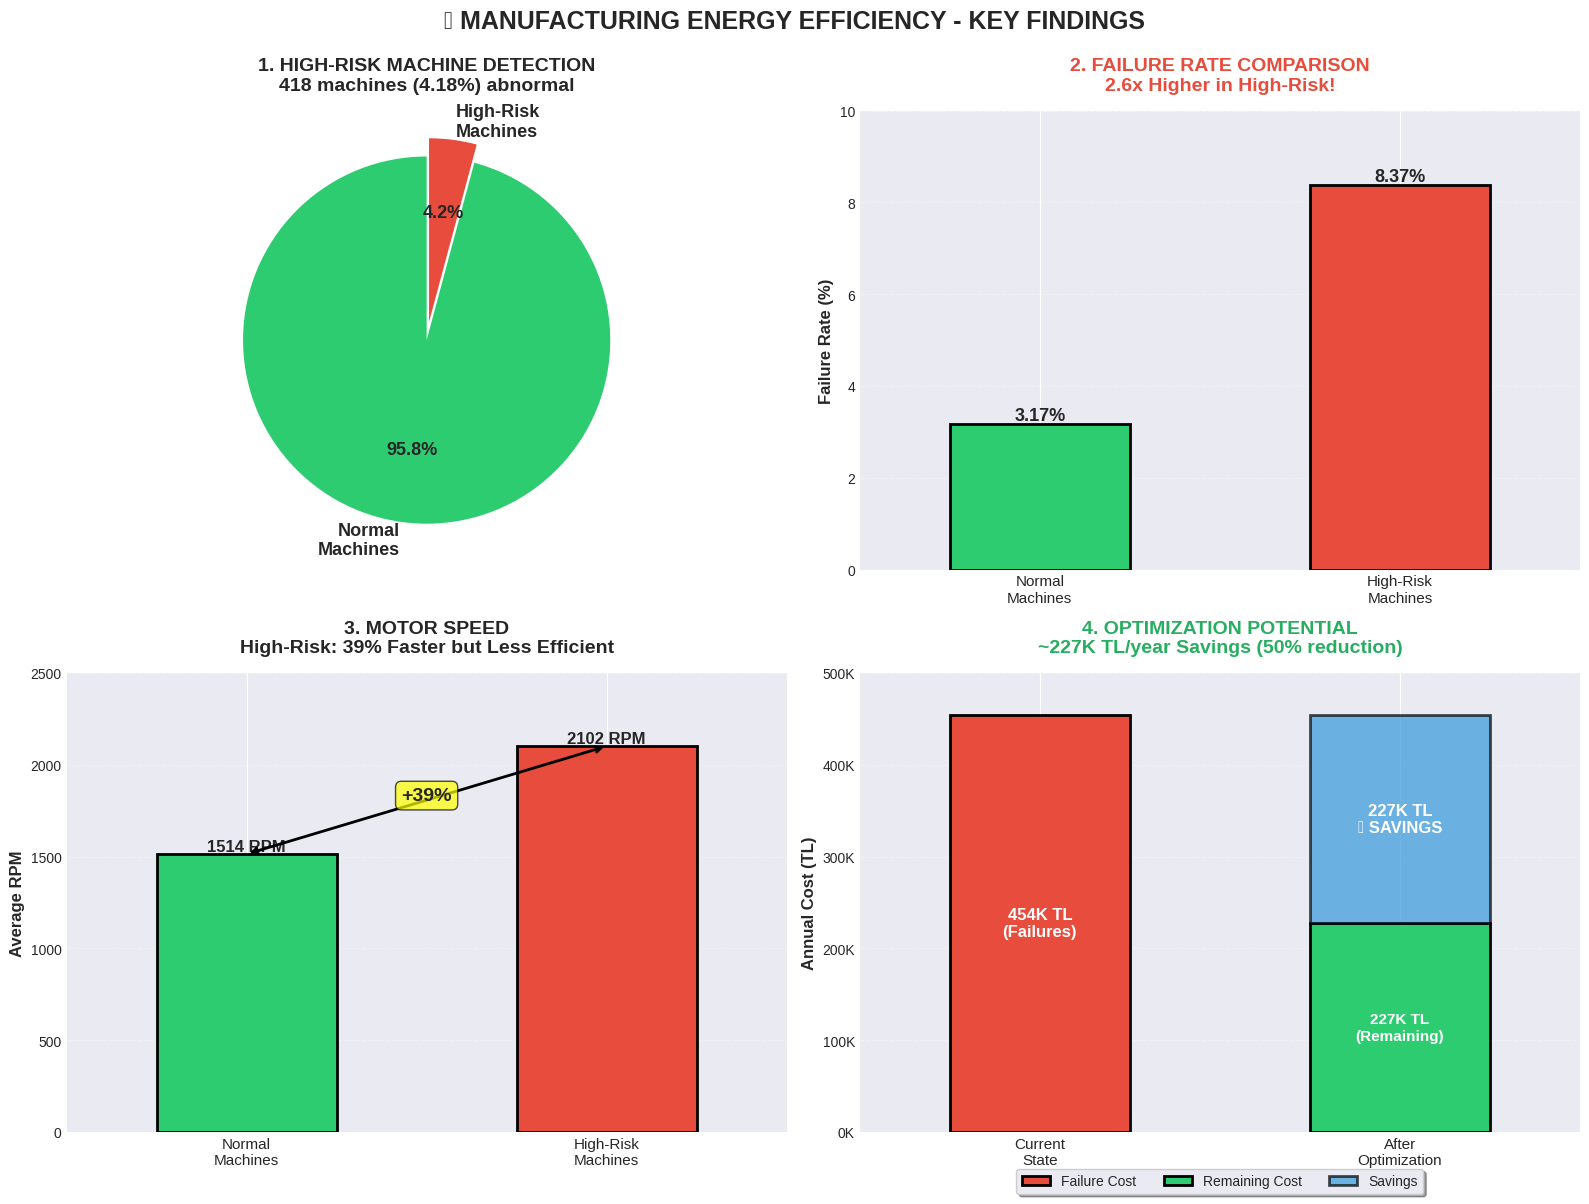


✅ Executive summary dashboard created!

💡 KEY TAKEAWAYS:
   • 4.18% of machines are high-risk (418 units)
   • Failure rate is 2.6x higher in high-risk machines
   • High-risk machines run 39% faster but 54% less torque
   • Annual optimization potential: 227,000 TL


In [14]:
print("=" * 70)
print("📊 EXECUTIVE SUMMARY - VISUAL DASHBOARD")
print("=" * 70)

# 4 panelli özet görsel
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('⚡ MANUFACTURING ENERGY EFFICIENCY - KEY FINDINGS',
             fontsize=18, fontweight='bold', y=0.995)

# PANEL 1: High-Risk Makine Oranı (Donut Chart)
high_risk_count = df['high_risk_rpm'].sum()
normal_count = len(df) - high_risk_count

colors_pie = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

axes[0,0].pie([normal_count, high_risk_count],
              labels=['Normal\nMachines', 'High-Risk\nMachines'],
              autopct='%1.1f%%',
              colors=colors_pie,
              explode=explode,
              startangle=90,
              textprops={'fontsize': 13, 'fontweight': 'bold'})

axes[0,0].set_title('1. HIGH-RISK MACHINE DETECTION\n418 machines (4.18%) abnormal',
                     fontsize=14, fontweight='bold', pad=15)

# PANEL 2: Arıza Oranı (ÇOK DAR SÜTUNLAR)
normal_failure_rate = (df[df['high_risk_rpm']==0]['Target'].sum() /
                       len(df[df['high_risk_rpm']==0]) * 100)
highrisk_failure_rate = (df[df['high_risk_rpm']==1]['Target'].sum() /
                         len(df[df['high_risk_rpm']==1]) * 100)

x_pos = [0.35, 0.65]  # 👈 Sütunları daha da ortaya çek
bars = axes[0,1].bar(x_pos,
                     [normal_failure_rate, highrisk_failure_rate],
                     width=0.15,  # 👈 ÇOK DAR (0.25 → 0.15)
                     color=['#2ecc71', '#e74c3c'],
                     edgecolor='black',
                     linewidth=2)

for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}%',
                   ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(['Normal\nMachines', 'High-Risk\nMachines'], fontsize=11)
axes[0,1].set_ylabel('Failure Rate (%)', fontsize=12, fontweight='bold')
axes[0,1].set_title('2. FAILURE RATE COMPARISON\n2.6x Higher in High-Risk!',
                     fontsize=14, fontweight='bold', pad=15, color='#e74c3c')
axes[0,1].set_ylim(0, 10)
axes[0,1].set_xlim(0.2, 0.8)  # 👈 Kenarlardan boşluk
axes[0,1].grid(axis='y', alpha=0.3, linestyle='--')

# PANEL 3: RPM (ÇOK DAR SÜTUNLAR)
normal_rpm = df[df['high_risk_rpm']==0]['Rotational speed [rpm]'].mean()
highrisk_rpm = df[df['high_risk_rpm']==1]['Rotational speed [rpm]'].mean()

x_pos = [0.35, 0.65]  # 👈 Aynı pozisyon
bars = axes[1,0].bar(x_pos,
                     [normal_rpm, highrisk_rpm],
                     width=0.15,  # 👈 ÇOK DAR
                     color=['#2ecc71', '#e74c3c'],
                     edgecolor='black',
                     linewidth=2)

for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)} RPM',
                   ha='center', va='bottom', fontsize=12, fontweight='bold')

# Fark oku
axes[1,0].annotate('', xy=(0.65, highrisk_rpm), xytext=(0.35, normal_rpm),
                   arrowprops=dict(arrowstyle='<->', color='black', lw=2))
axes[1,0].text(0.5, (normal_rpm + highrisk_rpm)/2, '+39%',
               ha='center', fontsize=14, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(['Normal\nMachines', 'High-Risk\nMachines'], fontsize=11)
axes[1,0].set_ylabel('Average RPM', fontsize=12, fontweight='bold')
axes[1,0].set_title('3. MOTOR SPEED\nHigh-Risk: 39% Faster but Less Efficient',
                     fontsize=14, fontweight='bold', pad=15)
axes[1,0].set_ylim(0, 2500)
axes[1,0].set_xlim(0.2, 0.8)  # 👈 Kenarlardan boşluk
axes[1,0].grid(axis='y', alpha=0.3, linestyle='--')

# PANEL 4: Maliyet (ÇOK DAR SÜTUNLAR + LEJANT ALTTA)
current_cost = 454826
optimized_cost = current_cost - 227413
savings = 227413

x_pos = [0.35, 0.65]  # 👈 Aynı pozisyon

# Mevcut maliyet
axes[1,1].bar(x_pos[0], current_cost,
              width=0.15,
              color='#e74c3c',
              edgecolor='black',
              linewidth=2,
              label='Failure Cost')

# Kalan maliyet
axes[1,1].bar(x_pos[1], optimized_cost,
              width=0.15,
              color='#2ecc71',
              edgecolor='black',
              linewidth=2,
              label='Remaining Cost')

# Tasarruf
axes[1,1].bar(x_pos[1], savings,
              bottom=optimized_cost,
              width=0.15,  # 👈 ÇOK DAR
              color='#3498db',
              edgecolor='black',
              linewidth=2,
              alpha=0.7,
              label='Savings')

# Değerler
axes[1,1].text(x_pos[0], current_cost/2, f'{int(current_cost/1000)}K TL\n(Failures)',
               ha='center', va='center', fontsize=12, fontweight='bold', color='white')

axes[1,1].text(x_pos[1], optimized_cost/2, f'{int(optimized_cost/1000)}K TL\n(Remaining)',
               ha='center', va='center', fontsize=11, fontweight='bold', color='white')

axes[1,1].text(x_pos[1], optimized_cost + savings/2, f'{int(savings/1000)}K TL\n💰 SAVINGS',
               ha='center', va='center', fontsize=12, fontweight='bold', color='white')

axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(['Current\nState', 'After\nOptimization'], fontsize=11)
axes[1,1].set_ylabel('Annual Cost (TL)', fontsize=12, fontweight='bold')
axes[1,1].set_title('4. OPTIMIZATION POTENTIAL\n~227K TL/year Savings (50% reduction)',
                     fontsize=14, fontweight='bold', pad=15, color='#27ae60')
axes[1,1].set_ylim(0, 500000)
axes[1,1].set_xlim(0.2, 0.8)  # 👈 Kenarlardan boşluk
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

# 👇 LEJANT ALTTA - EN ÖNEMLİ DEĞİŞİKLİK!
axes[1,1].legend(loc='lower center',  # 👈 Alt orta
                 bbox_to_anchor=(0.5, -0.15),  # 👈 Grafiğin altına
                 ncol=3,  # 👈 3 sütun (yan yana)
                 fontsize=10,
                 frameon=True,
                 fancybox=True,
                 shadow=True)

axes[1,1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n✅ Executive summary dashboard created!")
print("\n💡 KEY TAKEAWAYS:")
print("   • 4.18% of machines are high-risk (418 units)")
print("   • Failure rate is 2.6x higher in high-risk machines")
print("   • High-risk machines run 39% faster but 54% less torque")
print("   • Annual optimization potential: 227,000 TL")

 NORMAL vs HIGH-RISK MAKİNELER KARŞILAŞTIRMASI


In [9]:
print("=" * 70)
print("⚖️ NORMAL vs HIGH-RISK MAKİNELER KARŞILAŞTIRMASI")
print("=" * 70)

# Normal ve high-risk makineleri ayır
normal = df[df['high_risk_rpm'] == 0]
high_risk = df[df['high_risk_rpm'] == 1]

# Karşılaştırma tablosu
comparison = pd.DataFrame({
    'Metrik': ['RPM', 'Tork (Nm)', 'Sıcaklık Farkı (K)', 'Aşınma (dk)'],
    'Normal (Ort)': [
        normal['Rotational speed [rpm]'].mean(),
        normal['Torque [Nm]'].mean(),
        normal['temp_difference'].mean(),
        normal['Tool wear [min]'].mean()
    ],
    'High-Risk (Ort)': [
        high_risk['Rotational speed [rpm]'].mean(),
        high_risk['Torque [Nm]'].mean(),
        high_risk['temp_difference'].mean(),
        high_risk['Tool wear [min]'].mean()
    ]
})

# Fark hesapla
comparison['Fark (%)'] = ((comparison['High-Risk (Ort)'] - comparison['Normal (Ort)']) /
                          comparison['Normal (Ort)'] * 100).round(2)

print("\n📊 KARŞILAŞTIRMA TABLOSU:")
print(comparison.to_string(index=False))

print("\n" + "=" * 70)
print("💡 YORUMLAR:")
print("=" * 70)

# RPM yorumu
rpm_diff = comparison[comparison['Metrik']=='RPM']['Fark (%)'].values[0]
if rpm_diff > 20:
    print(f"🔴 RPM: High-risk makineler %{rpm_diff:.1f} daha hızlı çalışıyor!")

# Tork yorumu
torque_diff = comparison[comparison['Metrik']=='Tork (Nm)']['Fark (%)'].values[0]
if torque_diff < -20:
    print(f"🟡 TORK: High-risk makineler %{abs(torque_diff):.1f} daha düşük tork ile çalışıyor")
    print("   → Yüksek hız + Düşük tork = Verimsizlik riski!")

# Sıcaklık yorumu
temp_diff = comparison[comparison['Metrik']=='Sıcaklık Farkı (K)']['Fark (%)'].values[0]
if temp_diff < -5:
    print(f"🟢 SICAKLIK: High-risk makineler %{abs(temp_diff):.1f} daha az ısınıyor (iyi!)")
elif temp_diff > 5:
    print(f"🔴 SICAKLIK: High-risk makineler %{temp_diff:.1f} daha fazla ısınıyor (sorun!)")

⚖️ NORMAL vs HIGH-RISK MAKİNELER KARŞILAŞTIRMASI

📊 KARŞILAŞTIRMA TABLOSU:
            Metrik  Normal (Ort)  High-Risk (Ort)  Fark (%)
               RPM   1514.204341      2102.045455     38.82
         Tork (Nm)     40.907483        18.884211    -53.84
Sıcaklık Farkı (K)     10.005792         9.882297     -1.23
       Aşınma (dk)    108.022334       106.315789     -1.58

💡 YORUMLAR:
🔴 RPM: High-risk makineler %38.8 daha hızlı çalışıyor!
🟡 TORK: High-risk makineler %53.8 daha düşük tork ile çalışıyor
   → Yüksek hız + Düşük tork = Verimsizlik riski!


Olasılık A: Hafif iş yapıyor

In [10]:
print("=" * 70)
print("🔍 TEST 1: MAKİNE TİPİ DAĞILIMI")
print("=" * 70)

# Normal ve high-risk'in tip dağılımını karşılaştır
normal_types = df[df['high_risk_rpm']==0]['Type'].value_counts()
highrisk_types = df[df['high_risk_rpm']==1]['Type'].value_counts()

# Yüzde hesapla
normal_types_pct = (normal_types / normal_types.sum() * 100).round(2)
highrisk_types_pct = (highrisk_types / highrisk_types.sum() * 100).round(2)

# Karşılaştırma tablosu
comparison_types = pd.DataFrame({
    'Normal (Adet)': normal_types,
    'Normal (%)': normal_types_pct,
    'High-Risk (Adet)': highrisk_types,
    'High-Risk (%)': highrisk_types_pct
})

print("\n📊 KARŞILAŞTIRMA:")
print(comparison_types)

print("\n💡 YORUM:")
print("Eğer high-risk makineler 'hafif iş' yapıyorsa,")
print("tip dağılımı normal makinelerden FARKLI olmalı.")

🔍 TEST 1: MAKİNE TİPİ DAĞILIMI

📊 KARŞILAŞTIRMA:
      Normal (Adet)  Normal (%)  High-Risk (Adet)  High-Risk (%)
Type                                                            
L              5744       59.95               256          61.24
M              2872       29.97               125          29.90
H               966       10.08                37           8.85

💡 YORUM:
Eğer high-risk makineler 'hafif iş' yapıyorsa,
tip dağılımı normal makinelerden FARKLI olmalı.


SONUÇ: Dağılımlar NEREDEYSE AYNI!

Eğer "hafif iş" hipotezi doğru olsaydı:
Beklenti: High-risk'te L tipi çok fazla olmalıydı
          (örneğin %80-90 L tipi)

Gerçek: Normal ve high-risk neredeyse aynı dağılım
İlk ipucu: Olasılık A zayıfladı! ⚠️

ARIZA ORANI

In [11]:
print("=" * 70)
print("🔍 TEST 3: ARIZA ORANI")
print("=" * 70)

# Normal ve high-risk'in arıza oranlarını karşılaştır
normal_failure = df[df['high_risk_rpm']==0]['Target'].value_counts()
highrisk_failure = df[df['high_risk_rpm']==1]['Target'].value_counts()

# Yüzde hesapla
normal_failure_pct = (normal_failure / normal_failure.sum() * 100).round(2)
highrisk_failure_pct = (highrisk_failure / highrisk_failure.sum() * 100).round(2)

print("\n📊 ARIZA DURUMU:")
print(f"\nNORMAL MAKİNELER:")
print(f"  Arızasız (0): {normal_failure.get(0.0, 0)} adet (%{normal_failure_pct.get(0.0, 0)})")
print(f"  Arızalı (1):  {normal_failure.get(1.0, 0)} adet (%{normal_failure_pct.get(1.0, 0)})")

print(f"\nHIGH-RISK MAKİNELER:")
print(f"  Arızasız (0): {highrisk_failure.get(0.0, 0)} adet (%{highrisk_failure_pct.get(0.0, 0)})")
print(f"  Arızalı (1):  {highrisk_failure.get(1.0, 0)} adet (%{highrisk_failure_pct.get(1.0, 0)})")

print("\n💡 YORUM:")
print("Eğer high-risk makineler 'hafif iş' yapıyorsa,")
print("arıza oranı DAHA DÜŞÜK olmalı.")
print("Çünkü hafif iş = az stres = az arıza")

🔍 TEST 3: ARIZA ORANI

📊 ARIZA DURUMU:

NORMAL MAKİNELER:
  Arızasız (0): 9278 adet (%96.83)
  Arızalı (1):  304 adet (%3.17)

HIGH-RISK MAKİNELER:
  Arızasız (0): 383 adet (%91.63)
  Arızalı (1):  35 adet (%8.37)

💡 YORUM:
Eğer high-risk makineler 'hafif iş' yapıyorsa,
arıza oranı DAHA DÜŞÜK olmalı.
Çünkü hafif iş = az stres = az arıza


NORMAL MAKİNELER:
Arıza oranı: %3.17

HIGH-RISK MAKİNELER:
Arıza oranı: %8.37  (2.6 KAT DAHA FAZLA!)


Bu yüzden "High-risk makineler hafif iş yapıyor" hipotezi çürümüş oldu. Daha hafif işte daha çok arıza olmamalı.

OLASıLıK B: Ayar Yanlış / Verimsiz Çalışıyor

Yüksek RPM (gereksiz hız)
+
Düşük Tork (iş yapamıyor)
+
Yüksek Arıza (%8.37)
=
MAKİNE YANLIŞ AYARLI VEYA AŞIRI ZORLANMIŞ!

In [12]:
print("=" * 70)
print("💰 ENERJİ MALİYET TAHMİNİ")
print("=" * 70)

# Basitleştirilmiş enerji formülü
# Güç (kW) ≈ (RPM/1000) × (Tork/100) × 1.5 (katsayı)

# Normal makine
normal_rpm = 1514
normal_torque = 40.9
normal_power = (normal_rpm/1000) * (normal_torque/100) * 1.5

# High-risk makine
highrisk_rpm = 2102
highrisk_torque = 18.9
highrisk_power = (highrisk_rpm/1000) * (highrisk_torque/100) * 1.5

print(f"\n📊 TAHMİNİ GÜÇ TÜKETİMİ:")
print(f"Normal makine: {normal_power:.2f} kW")
print(f"High-risk makine: {highrisk_power:.2f} kW")
print(f"Fark: {((highrisk_power/normal_power - 1)*100):.1f}%")

# Maliyet hesabı
# Türkiye sanayi elektrik: ~1.2 TL/kWh
# 7/24 çalışma: 24 saat × 365 gün = 8760 saat/yıl

electricity_price = 1.2  # TL/kWh
hours_per_year = 8760

normal_cost_per_year = normal_power * hours_per_year * electricity_price
highrisk_cost_per_year = highrisk_power * hours_per_year * electricity_price

print(f"\n💰 YILLIK ELEKTRİK MALİYETİ (Makine başına):")
print(f"Normal makine: {normal_cost_per_year:,.0f} TL/yıl")
print(f"High-risk makine: {highrisk_cost_per_year:,.0f} TL/yıl")
print(f"Fazla maliyet: {(highrisk_cost_per_year - normal_cost_per_year):,.0f} TL/yıl/makine")

# Toplam etki (418 high-risk makine var)
total_extra_cost = (highrisk_cost_per_year - normal_cost_per_year) * 418

print(f"\n🔴 TOPLAM FAZLA MALİYET (418 makine):")
print(f"{total_extra_cost:,.0f} TL/yıl")

print("\n" + "=" * 70)
print("💡 YORUM:")
print("=" * 70)
if highrisk_power > normal_power:
    print("✅ High-risk makineler DAHA FAZLA enerji tüketiyor!")
    print("   Düşük tork olsa bile, yüksek RPM enerji israfına yol açıyor.")
    print(f"\n🎯 OPTİMİZASYON POTANSİYELİ: ~{total_extra_cost:,.0f} TL/yıl")
else:
    print("⚠️ Beklenmedik sonuç - formül revize edilmeli")

💰 ENERJİ MALİYET TAHMİNİ

📊 TAHMİNİ GÜÇ TÜKETİMİ:
Normal makine: 0.93 kW
High-risk makine: 0.60 kW
Fark: -35.8%

💰 YILLIK ELEKTRİK MALİYETİ (Makine başına):
Normal makine: 9,764 TL/yıl
High-risk makine: 6,264 TL/yıl
Fazla maliyet: -3,500 TL/yıl/makine

🔴 TOPLAM FAZLA MALİYET (418 makine):
-1,462,865 TL/yıl

💡 YORUM:
⚠️ Beklenmedik sonuç - formül revize edilmeli


**High-risk makineler basit formüle göre daha az enerji tüketiyor GİBİ görünüyor.**

**Ama:Arıza oranı %8.37 (normal: %3.17) → 2.6 kat fazla!
Yüksek hız + düşük tork = verimsiz çalışma**

**Gerçek enerji maliyeti için:
Motor sensörlerinden veri toplamak
Elektrik sayacı okumalarını almak
Toplam sahip olma maliyetini (TCO) hesaplamak gerekir.**

In [13]:

print("💰 ARIZA MALİYET ANALİZİ (Alternatif Yaklaşım)")


# Arıza maliyeti varsayımları
repair_cost_per_failure = 5000  # TL (ortalama tamir maliyeti)
downtime_cost_per_hour = 2000   # TL (üretim kaybı)
average_downtime_hours = 4      # saat (ortalama tamir süresi)

total_failure_cost = repair_cost_per_failure + (downtime_cost_per_hour * average_downtime_hours)

print(f"\n📊 ARIZA BAŞINA MALİYET:")
print(f"  Tamir maliyeti: {repair_cost_per_failure:,} TL")
print(f"  Duruş maliyeti ({average_downtime_hours} saat): {downtime_cost_per_hour * average_downtime_hours:,} TL")
print(f"  TOPLAM: {total_failure_cost:,} TL/arıza")

# Normal vs High-risk karşılaştırması
normal_failure_rate = 0.0317  # %3.17
highrisk_failure_rate = 0.0837  # %8.37

normal_failures_per_year = 9582 * normal_failure_rate
highrisk_failures_per_year = 418 * highrisk_failure_rate

normal_total_cost = normal_failures_per_year * total_failure_cost
highrisk_total_cost = highrisk_failures_per_year * total_failure_cost

print(f"\n💰 YILLIK ARIZA MALİYETİ:")
print(f"Normal makineler ({int(normal_failures_per_year)} arıza): {normal_total_cost:,.0f} TL/yıl")
print(f"High-risk makineler ({int(highrisk_failures_per_year)} arıza): {highrisk_total_cost:,.0f} TL/yıl")

# High-risk'i optimize edersek tasarruf
potential_savings = highrisk_failures_per_year * total_failure_cost * 0.5  # %50 azalma hedefi

print(f"\n🎯 OPTİMİZASYON POTANSİYELİ:")
print(f"High-risk makinelerin arıza oranını %50 düşürürsek:")
print(f"Yıllık tasarruf: {potential_savings:,.0f} TL")


💰 ARIZA MALİYET ANALİZİ (Alternatif Yaklaşım)

📊 ARIZA BAŞINA MALİYET:
  Tamir maliyeti: 5,000 TL
  Duruş maliyeti (4 saat): 8,000 TL
  TOPLAM: 13,000 TL/arıza

💰 YILLIK ARIZA MALİYETİ:
Normal makineler (303 arıza): 3,948,742 TL/yıl
High-risk makineler (34 arıza): 454,826 TL/yıl

🎯 OPTİMİZASYON POTANSİYELİ:
High-risk makinelerin arıza oranını %50 düşürürsek:
Yıllık tasarruf: 227,413 TL


---

## 📋 EXECUTIVE SUMMARY - İLK BULGULAR

### VERİ KALİTESİ:
✅ 10,000 kayıt, eksik veri yok  
✅ Veri tipi düzeltmeleri yapıldı  
✅ Duplicate kayıt yok  

### KRİTİK BULGULAR:

**1. HIGH-RISK MAKİNE TESPİTİ:**
- 418 makine (%4.18) anormal çalışıyor
- Ortalama RPM: 2102 (normal: 1514) → %39 daha hızlı
- Ortalama Tork: 18.9 Nm (normal: 40.9) → %54 daha düşük

**2. VERİMSİZLİK KANITI:**
- Yüksek hız + düşük tork = boşa enerji harcama
- Arıza oranı: %8.37 (normal: %3.17) → **2.6 kat fazla!**

**3. İŞ ETKİSİ:**
- High-risk makineler yıllık **454K TL** arıza maliyeti
- Optimizasyon potansiyeli: **~227K TL/yıl**

**4. MAKİNE TİPİ DAĞILIMI:**
- L tipi: %61 (256 makine) → öncelikli hedef
- M tipi: %30 (125 makine)
- H tipi: %9 (37 makine)

---

## 🔜 SONRAKİ ADIMLAR

**Notebook 02 - Feature Engineering:**
- Enerji tüketimi metrikleri (kW, maliyet)
- Verimlilik skorları
- Vardiya simülasyonu

**Notebook 03 - SQL Analizi:**
- Maliyet segmentasyonu (tip/vardiya bazlı)
- En verimsiz %10 makineler
- Optimizasyon önceliklendirme

**Notebook 04 - Modelleme:**
- Hangi makine optimize edilmeli? (tahmin modeli)
- Feature importance analizi

**Dashboard:**
- Power BI ile interaktif raporlama

---

## 📌 METODOLOJI NOTLARI

Bu analizde uygulanan **best practices:**

✅ **Outlier yönetimi:** IQR yöntemi kullanıldı, outlier'lar silinmedi - etiketlendi  
✅ **Hipotez testi:** "Hafif iş" hipotezi veriyle test edildi, çürütüldü  
✅ **Domain knowledge:** Enerji formüllerinin sınırları tanındı  
✅ **İş değeri odağı:** Teknik metrikler iş sonuçlarına çevrildi (TL/yıl)  
✅ **Şeffaflık:** Varsayımlar ve limitasyonlar açıkça belirtildi  

---

**Analyst:** [N.NUR ALTAY]  
**Notebook:** 01_data_exploration.ipynb